# 문제 5·6 — 점군 자세 추정 (PCA · Kabsch · 최소제곱) 과 자세 궤적 애니메이션

카메라가 본 점군에서 물체가 **어느 방향으로 놓였는지**를 추정하고,
그 자세를 목표로 삼아 현재 자세에서 이동하는 궤적을 만들어 애니메이션으로 시연합니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 것 |
|---|---|---|
| 5-1 | 점군 공분산 고유분해로 **주축 추출**, 주축 3D + 고유값 막대그래프 (그림 코드 제공) | `pca_axes` |
| 5-2 | **PCA 의 한계** — 구형 점군에서 주축이 불안정해지는 것을 관찰하고 고유값으로 설명 | — |
| 5-3 | 알려진 회전 + 노이즈 → **Kabsch** 로 회전 역추정, 정합 전후 그림 (그림 코드 제공) | `kabsch` |
| 5-4 | 노이즈 **0 ~ 0.25** × 점 개수 **30·90·270** 오차 곡선 (그림 코드 제공) | — |
| 5-5 | 이상치 섞은 점군에 **최소제곱 평면 피팅** → 잔차 큰 점 제거 → 오차 개선 확인 | `fit_plane_lstsq`, `remove_outliers` |
| 6-1 | 추정 자세를 **목표 자세**로, SLERP(자세) + 스플라인(위치) 동시 보간 궤적 | — |
| 6-2 | 궤적 **애니메이션** 재생 + `demo.gif` 저장, 궤적 품질 정량 평가 (코드 제공) | — |
| 6-3 | `presentation.md` 발표 자료, 세 노트북 재실행 | (마크다운) |

> 시드는 반드시 `np.random.default_rng(42)`. 시드가 다르면 오차 수치가 채점 기준과 달라집니다.
> `# --- 검증 ---` 셀과 그림·애니메이션 셀은 **제공된 코드**입니다. 수정하지 말고 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.coordinate_chain import default_chain                                            # 모듈 ③
from src.rotation import axis_angle_from_matrix, rodrigues, rot_x, rot_y, rot_z          # 모듈 ③
from src.transform import inv_T, make_T, transform_points                                 # 모듈 ③
from src.quaternion import matrix_to_quaternion, quaternion_to_matrix, slerp              # 문제 3
from src.trajectory import cubic_spline_interp, finite_diff, linear_interp                # 문제 4
from src.pose_estimation import fit_plane_lstsq, kabsch, pca_axes, remove_outliers, rotation_angle_deg   # 문제 5
from src.plot3d import animate_frames, plot_point_cloud                                   # 제공

rng = np.random.default_rng(42)   # 시드 고정 — 바꾸지 마세요
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def is_rotation(R):
    R = np.asarray(R)
    return R.shape == (3, 3) and np.allclose(R.T @ R, np.eye(3)) and np.isclose(np.linalg.det(R), 1.0)   # 검산용


# --- 3D 그림 헬퍼 (제공 코드 — src/plot3d.py 와 같은 함수) ------------------------

def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T(4x4) 가 나타내는 좌표계를 x(빨강)·y(초록)·z(파랑) 화살표로 그린다."""
    T = np.asarray(T, dtype=float)
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold", alpha=max(alpha, 0.6))


def setup_axes(ax, title="", lim=1.0, center=(0.0, 0.0, 0.0)):
    """축 범위를 center 를 중심으로 +-lim 으로 맞추고 라벨·제목을 붙인다 (등축)."""
    cx, cy, cz = center
    ax.set_xlim(cx - lim, cx + lim)
    ax.set_ylim(cy - lim, cy + lim)
    ax.set_zlim(cz - lim, cz + lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("ROOT =", ROOT)

ROOT = /home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student


## 5-1. PCA 주축 추출

점군의 공분산 $C=\frac{1}{N-1}X^{\mathsf{T}}X$ ($X$ 는 중심을 뺀 점군) 를 고유분해하면
고유벡터가 **분산이 가장 큰 방향(주축)**, 고유값이 그 방향의 분산입니다.
길쭉한 물체라면 첫 주축이 물체의 긴 축과 나란합니다.

아래 점군 생성 코드는 **그대로** 쓰세요 (시드 42, `n_points = 240`, 표준편차 0.35 / 0.10 / 0.05).

**할 일** — `src/pose_estimation.py` 의 `pca_axes` 를 구현하세요. 반환은 `(axes, eigvals, centroid)`
이며 `axes` 의 열이 고유값 **내림차순** 주축이고 `det(axes) = +1` 이어야 합니다.

In [2]:
# --- 점군 생성 (지시문 코드 — 바꾸지 마세요) ---
import numpy as np

rng = np.random.default_rng(42)   # 시드 고정 — 바꾸지 마세요

# 길쭉한 상자 모양의 물체 점군 (x방향으로 길다)
n_points = 240
pts = np.column_stack([
    rng.normal(0.0, 0.35, n_points),   # x — 긴 축
    rng.normal(0.0, 0.10, n_points),   # y
    rng.normal(0.0, 0.05, n_points),   # z — 가장 짧은 축
])
print("pts shape:", pts.shape)

pts shape: (240, 3)


In [3]:
# TODO: 아래 변수를 만드세요 -> axes, eigvals, centroid
#   axes, eigvals, centroid = pca_axes(pts)

axes, eigvals, centroid = pca_axes(pts)

print("주축 0 (긴 축):", axes[:, 0])
print("주축 1:", axes[:, 1])
print("주축 2 (짧은 축):", axes[:, 2])
print("고유값:", eigvals)
print("표준편차 추정 sqrt(λ):", np.sqrt(eigvals))
print("생성 표준편차 (0.35, 0.10, 0.05) 와 비교:", np.allclose(np.sqrt(eigvals), [0.35, 0.10, 0.05], rtol=0.2))
print("중심:", centroid)


주축 0 (긴 축): [-0.999269  0.037327  0.008226]
주축 1: [ 0.037052  0.99882  -0.031402]
주축 2 (짧은 축): [-0.009388 -0.031074 -0.999473]
고유값: [0.0995   0.010287 0.002548]
표준편차 추정 sqrt(λ): [0.315436 0.101423 0.050476]
생성 표준편차 (0.35, 0.10, 0.05) 와 비교: True
중심: [-0.016453  0.002733 -0.005471]


/tmp/ipykernel_58064/78413060.py:19: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/78413060.py:19: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/78413060.py:19: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/78413060.py:19: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/78413060.py:19: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/78413060.py:19: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/78413060.py:19: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/

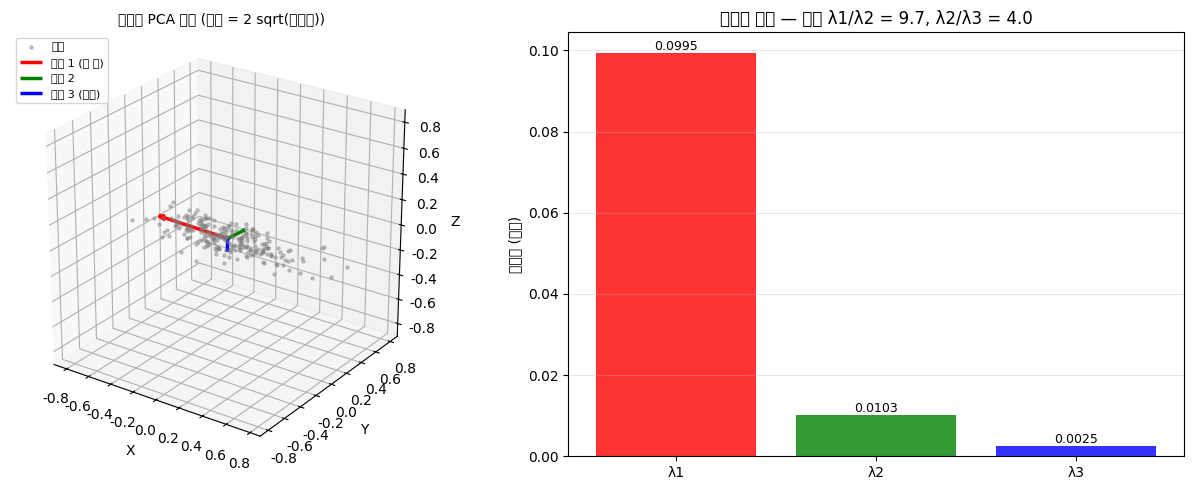

In [4]:
# --- 그림 (제공 코드) — 점군 위의 주축 + 고유값 막대 ---
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
setup_axes(ax, "점군과 PCA 주축 (길이 = 2 sqrt(고유값))", lim=0.9, center=centroid)
plot_point_cloud(ax, pts, color="tab:gray", s=5, alpha=0.4, label="점군")
for k, (c, name) in enumerate(zip(["r", "g", "b"], ["주축 1 (긴 축)", "주축 2", "주축 3 (법선)"])):
    v = axes[:, k] * 2.0 * np.sqrt(eigvals[k])
    ax.quiver(*centroid, *v, color=c, lw=2.5, arrow_length_ratio=0.1, label=name)
ax.legend(fontsize=8, loc="upper left")
ax.view_init(elev=25, azim=-55)

ax2 = fig.add_subplot(1, 2, 2)
bars = ax2.bar(["λ1", "λ2", "λ3"], eigvals, color=["r", "g", "b"], alpha=0.8)
for b, v in zip(bars, eigvals):
    ax2.text(b.get_x() + b.get_width() / 2, v, "{:.4f}".format(v), ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("고유값 (분산)")
ax2.set_title("고유값 크기 — 비율 λ1/λ2 = {:.1f}, λ2/λ3 = {:.1f}".format(eigvals[0] / eigvals[1], eigvals[1] / eigvals[2]))
ax2.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
X = pts - pts.mean(axis=0)
C = X.T @ X / (len(pts) - 1)
ok = check("centroid == 점군 평균", np.allclose(centroid, pts.mean(axis=0)))
ok &= check("고유값이 내림차순", eigvals[0] >= eigvals[1] >= eigvals[2] > 0)
ok &= check("axes 는 회전행렬 (직교, det=+1)", is_rotation(axes))
ok &= check("axes 가 공분산을 대각화한다 (axes.T C axes == diag(eigvals))",
            np.allclose(axes.T @ C @ axes, np.diag(eigvals)))
ok &= check("첫 주축이 x축과 나란 (|cos| > 0.99)", abs(axes[0, 0]) > 0.99)
ok &= check("세 번째 주축이 z축과 나란 (|cos| > 0.99)", abs(axes[2, 2]) > 0.99)
ok &= check("고유값의 제곱근이 생성 표준편차 (0.35, 0.10, 0.05) 와 20% 이내",
            np.allclose(np.sqrt(eigvals), [0.35, 0.10, 0.05], rtol=0.2))
ok &= check("np.linalg.eigh 와 일치 (검산)", np.allclose(np.sort(np.linalg.eigvalsh(C))[::-1], eigvals))
print("\n5-1 전체 통과:", ok)

[PASS] centroid == 점군 평균
[PASS] 고유값이 내림차순
[PASS] axes 는 회전행렬 (직교, det=+1)
[PASS] axes 가 공분산을 대각화한다 (axes.T C axes == diag(eigvals))
[PASS] 첫 주축이 x축과 나란 (|cos| > 0.99)
[PASS] 세 번째 주축이 z축과 나란 (|cos| > 0.99)
[PASS] 고유값의 제곱근이 생성 표준편차 (0.35, 0.10, 0.05) 와 20% 이내
[PASS] np.linalg.eigh 와 일치 (검산)

5-1 전체 통과: True


## 5-2. PCA 의 한계 — 구형에 가까운 점군

세 방향 분산이 비슷하면 고유값이 거의 같아지고, 고유벡터는 **어느 방향이든 될 수 있습니다**
(고유값이 중복되면 고유공간이 2차원 이상이 되어 방향이 정해지지 않습니다).
샘플이 조금만 달라져도 첫 주축이 크게 튑니다.

**할 일** — 표준편차가 (0.20, 0.19, 0.18) 인 구형 점군을 여러 번 새로 뽑아 첫 주축의 방향이
시행마다 얼마나 흔들리는지 재고, 길쭉한 점군과 비교하세요.

### 관찰 내용과 이유 (고유값 관점)

- 길쭉한 점군의 첫 주축 흔들림 [deg]: `___` / 구형 점군: `___`
- 고유값 비율 λ1/λ2 — 길쭉: `___` / 구형: `___`
- 왜 불안정해지는가: `___`

In [6]:
N_TRIALS_PCA = 20
STD_LONG = np.array([0.35, 0.10, 0.05])
STD_SPHERE = np.array([0.20, 0.19, 0.18])


def make_cloud(n, std, rng):
    """세 축 표준편차 std 로 n 개 점을 만든다 (제공 코드)."""
    return rng.normal(0.0, std, (n, 3))


def axis_spread_deg(first_axes):
    """첫 주축 벡터들이 평균 방향에서 벗어난 각도의 최댓값 [deg] (부호 무시) (제공 코드)."""
    A = np.array(first_axes)
    A = A * np.sign(A @ A[0])[:, None]                       # 부호를 첫 번째와 맞춘다
    mean_dir = A.mean(axis=0)
    mean_dir /= np.linalg.norm(mean_dir)
    return float(np.rad2deg(np.arccos(np.clip(np.abs(A @ mean_dir), -1.0, 1.0)).max()))

long_first, sphere_first, ratio_long_all, ratio_sphere_all = [], [], [], []
for _ in range(N_TRIALS_PCA):
    ax_l, ev_l, _ = pca_axes(make_cloud(n_points, STD_LONG, rng))
    long_first.append(ax_l[:, 0])
    ratio_long_all.append(ev_l[0] / ev_l[1])
    ax_s, ev_s, _ = pca_axes(make_cloud(n_points, STD_SPHERE, rng))
    sphere_first.append(ax_s[:, 0])
    ratio_sphere_all.append(ev_s[0] / ev_s[1])

spread_long = axis_spread_deg(long_first)
spread_sphere = axis_spread_deg(sphere_first)
ratio_long = float(np.mean(ratio_long_all))
ratio_sphere = float(np.mean(ratio_sphere_all))

print("흔들림 길쭉:", spread_long, "도 / 구형:", spread_sphere, "도")
print("λ1/λ2 길쭉:", ratio_long, " / 구형:", ratio_sphere)


흔들림 길쭉: 2.4810039371662653 도 / 구형: 72.72925752659266 도
λ1/λ2 길쭉: 12.371765944782776  / 구형: 1.1933863938157494


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("길쭉한 점군: 첫 주축 흔들림 < 5도", spread_long < 5.0)
ok &= check("구형 점군: 첫 주축 흔들림 > 20도 (불안정)", spread_sphere > 20.0)
ok &= check("구형이 길쭉보다 훨씬 불안정 (5배 이상)", spread_sphere > 5.0 * spread_long)
ok &= check("길쭉한 점군 λ1/λ2 > 5", ratio_long > 5.0)
ok &= check("구형 점군 λ1/λ2 < 1.6 (고유값이 거의 같다)", ratio_sphere < 1.6)
print("\n5-2 전체 통과:", ok)

[PASS] 길쭉한 점군: 첫 주축 흔들림 < 5도
[PASS] 구형 점군: 첫 주축 흔들림 > 20도 (불안정)
[PASS] 구형이 길쭉보다 훨씬 불안정 (5배 이상)
[PASS] 길쭉한 점군 λ1/λ2 > 5
[PASS] 구형 점군 λ1/λ2 < 1.6 (고유값이 거의 같다)

5-2 전체 통과: True


## 5-3. Kabsch — 알려진 회전을 역추정

기준 점군 $P$ 에 참값 회전 $R_{true}$·병진 $t_{true}$ 를 적용하고 노이즈를 더해 $Q$ 를 만든 뒤,
$Q\approx PR^{\mathsf{T}}+t$ 를 가장 잘 만족하는 $R$ 을 SVD 로 구합니다 (대응이 알려진 경우).

$$H=X^{\mathsf{T}}Y,\quad H=U\Sigma V^{\mathsf{T}},\quad R=V\,\mathrm{diag}(1,1,\det(VU^{\mathsf{T}}))\,U^{\mathsf{T}}$$

**할 일** — `kabsch` 를 구현하고 참값과의 각도 오차를 구하세요.

In [8]:
# --- 참값 변환과 관측 (제공 코드) ---
R_true = rodrigues([1.0, 2.0, 0.5], np.deg2rad(40.0))
t_true = np.array([0.10, -0.05, 0.02])
NOISE_STD = 0.01
pts_rot = pts @ R_true.T + t_true + rng.normal(0.0, NOISE_STD, pts.shape)

R_est, t_est = kabsch(pts, pts_rot)
angle_err_deg = rotation_angle_deg(R_est, R_true)
pts_aligned = pts @ R_est.T + t_est
rms_before = float(np.sqrt(np.mean(np.sum((pts - pts_rot) ** 2, axis=1))))
rms_after = float(np.sqrt(np.mean(np.sum((pts_aligned - pts_rot) ** 2, axis=1))))

print("R_est =\n", R_est)
print("R_true =\n", R_true)
print("각도 오차 [deg]:", angle_err_deg)
print("병진 오차 [m]:", np.linalg.norm(t_est - t_true), t_est - t_true)
print("정합 전 RMS:", rms_before, " 정합 후 RMS:", rms_after)


R_est =
 [[ 0.812711 -0.051584  0.58038 ]
 [ 0.227368  0.945183 -0.234379]
 [-0.536475  0.322442  0.779888]]
R_true =
 [[ 0.810607 -0.051142  0.583353]
 [ 0.229394  0.944296 -0.235973]
 [-0.53879   0.325098  0.777185]]
각도 오차 [deg]: 0.2581711806335743
병진 오차 [m]: 8.710980062440913e-05 [-0.000086 -0.000014 -0.000004]
정합 전 RMS: 0.23370013647615923  정합 후 RMS: 0.017759364770123624


/tmp/ipykernel_58064/1557600355.py:16: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/1557600355.py:16: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/1557600355.py:16: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/1557600355.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/1557600355.py:16: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/1557600355.py:16: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/1557600355.py:16: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  f

/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: 

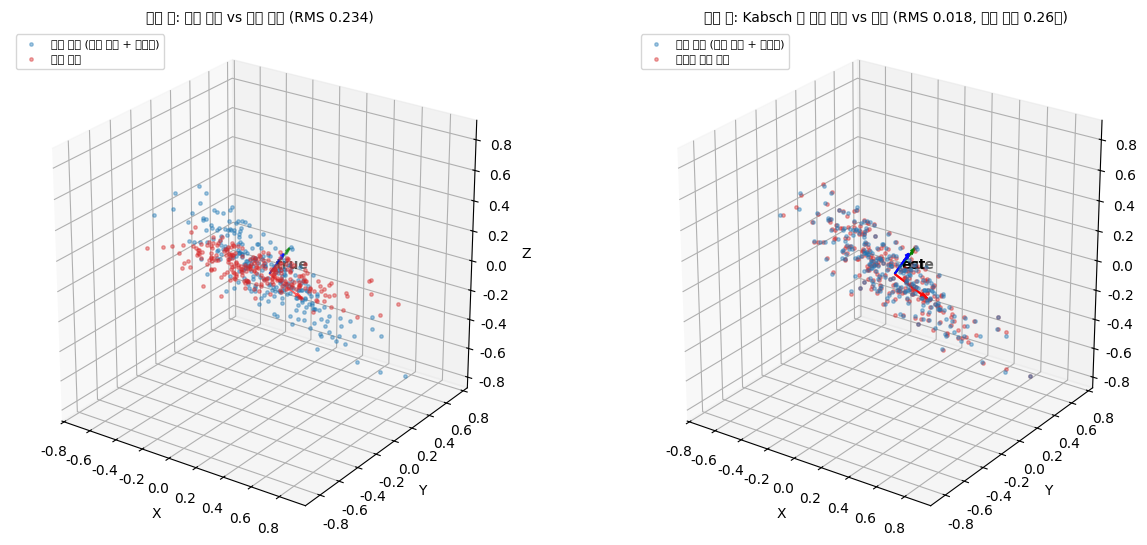

In [9]:
# --- 그림 (제공 코드) — 정합 전 / 후 ---
fig = plt.figure(figsize=(13, 5.5))
for k, (P, title) in enumerate([
    (pts, "정합 전: 기준 점군 vs 관측 점군 (RMS {:.3f})".format(rms_before)),
    (pts_aligned, "정합 후: Kabsch 로 맞춘 점군 vs 관측 (RMS {:.3f}, 각도 오차 {:.2f}도)".format(rms_after, angle_err_deg)),
]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    setup_axes(ax, title, lim=0.9, center=pts_rot.mean(axis=0))
    plot_point_cloud(ax, pts_rot, color="tab:blue", s=6, alpha=0.4, label="관측 점군 (참값 회전 + 노이즈)")
    plot_point_cloud(ax, P, color="tab:red", s=6, alpha=0.4, label="기준 점군" if k == 0 else "정합된 기준 점군")
    draw_frame(ax, make_T(R_true, t_true), scale=0.25, name="true", alpha=0.6)
    if k == 1:
        draw_frame(ax, make_T(R_est, t_est), scale=0.25, name="est")
    ax.legend(fontsize=8, loc="upper left")
    ax.view_init(elev=25, azim=-55)
fig.tight_layout()
plt.show()

In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("R_est 는 회전행렬 (det=+1)", is_rotation(R_est))
ok &= check("각도 오차 < 3도", angle_err_deg < 3.0)
ok &= check("병진 오차 < 0.02 m", np.linalg.norm(t_est - t_true) < 0.02)
ok &= check("정합 후 RMS < 정합 전 RMS", rms_after < rms_before)
ok &= check("정합 후 RMS 가 노이즈 수준 (< 3 * NOISE_STD)", rms_after < 3.0 * NOISE_STD)
# rotation_angle_deg 는 arccos((trace-1)/2) 라 theta ~ 0 근처에서 오차가 sqrt 로 증폭된다.
# 배정밀도에서 각도 오차의 바닥이 약 1e-6 도이므로 문턱을 그보다 넉넉히 잡는다.
ok &= check("노이즈 없는 관측에서는 정확히 복원 (< 1e-4 도)", rotation_angle_deg(kabsch(pts, pts @ R_true.T + t_true)[0], R_true) < 1e-4)
R_refl, _ = kabsch(pts, pts @ np.diag([1.0, 1.0, -1.0]).T)
ok &= check("반사된 관측에도 반사행렬이 아닌 회전행렬을 돌려준다", is_rotation(R_refl))
print("\n5-3 전체 통과:", ok)

[PASS] R_est 는 회전행렬 (det=+1)
[PASS] 각도 오차 < 3도
[PASS] 병진 오차 < 0.02 m
[PASS] 정합 후 RMS < 정합 전 RMS
[PASS] 정합 후 RMS 가 노이즈 수준 (< 3 * NOISE_STD)
[PASS] 노이즈 없는 관측에서는 정확히 복원 (< 1e-4 도)
[PASS] 반사된 관측에도 반사행렬이 아닌 회전행렬을 돌려준다

5-3 전체 통과: True


## 5-4. 오차의 정량 평가 — 노이즈 × 점 개수

노이즈 표준편차를 **0 에서 0.25 까지** 키우며 Kabsch 각도 오차를 재고, 점 개수를 **30 · 90 · 270** 으로 바꿔
세 계열을 한 그래프에 그립니다. 시행마다 값이 튀므로 `N_TRIALS` 번 평균합니다.

**할 일** — `err_table[i, j]` = 점 개수 `point_counts[i]`, 노이즈 `noise_levels[j]` 에서의 평균 각도 오차 [deg].

### 해석

- 노이즈가 커질 때 오차가 어떻게 커지는가: `___`
- 점이 많을수록 어떻게 달라지는가 (대략 몇 배): `___`
- 그 이유 (평균으로 노이즈가 상쇄되는 원리, $1/\sqrt{N}$): `___`

In [11]:
noise_levels = np.linspace(0.0, 0.25, 11)
point_counts = [30, 90, 270]
N_TRIALS = 5

err_table = np.zeros((len(point_counts), len(noise_levels)))
for i, n in enumerate(point_counts):
    for j, sigma in enumerate(noise_levels):
        errs = []
        for _ in range(N_TRIALS):
            P = make_cloud(n, STD_LONG, rng)
            Q = P @ R_true.T + t_true + rng.normal(0.0, sigma, P.shape)
            R_hat, _ = kabsch(P, Q)
            errs.append(rotation_angle_deg(R_hat, R_true))
        err_table[i, j] = float(np.mean(errs))

print(f"{'n/sigma':>8}" + "".join(f"{s:>10.3f}" for s in noise_levels))
for n, row in zip(point_counts, err_table):
    print(f"{n:>8}" + "".join(f"{v:>10.4f}" for v in row))


 n/sigma     0.000     0.025     0.050     0.075     0.100     0.125     0.150     0.175     0.200     0.225     0.250
      30    0.0000    1.9531    4.9238    4.9549    8.2736    8.0579   16.1425   17.5349   21.8309   16.0351   19.7296
      90    0.0000    1.5857    2.4483    3.6171    3.6070    5.3438    5.9901   12.0122   11.8111    8.8267   17.9199
     270    0.0000    0.4956    2.5563    2.2825    3.1349    5.9409    3.6518    4.1107    3.9937    5.4154    8.6982


/tmp/ipykernel_58064/2908478328.py:8: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2908478328.py:8: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2908478328.py:8: UserWarning: Glyph 51592 (\N{HANGUL SYLLABLE JEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2908478328.py:8: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2908478328.py:8: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2908478328.py:8: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2908478328.py:8: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_lay

/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170:

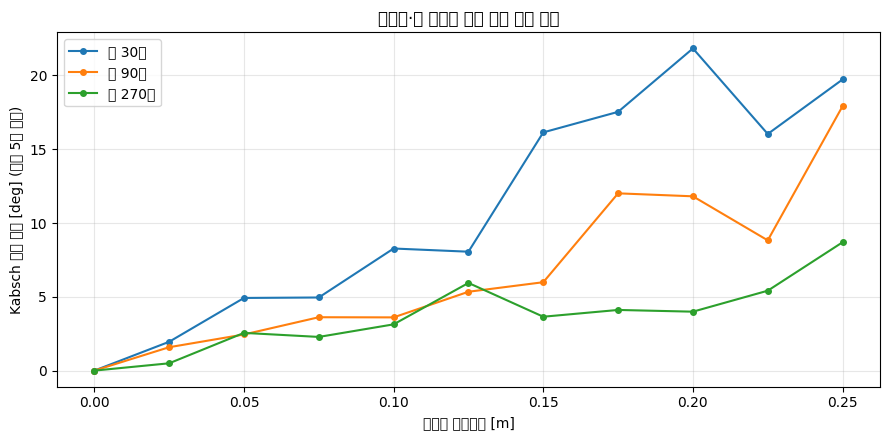

In [12]:
# --- 그래프 (제공 코드 — 그대로 쓰면 됩니다) ---
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, n in enumerate(point_counts):
    ax.plot(noise_levels, err_table[i], "o-", ms=4, label="점 {}개".format(n))
ax.set_xlabel("노이즈 표준편차 [m]"); ax.set_ylabel("Kabsch 각도 오차 [deg] (시행 {}회 평균)".format(N_TRIALS))
ax.set_title("노이즈·점 개수에 따른 자세 추정 오차")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("err_table shape == (3, 11)", np.shape(err_table) == (len(point_counts), len(noise_levels)))
ok &= check("노이즈 0 이면 오차 ~ 0 (< 1e-4도)", np.all(err_table[:, 0] < 1e-4))
ok &= check("노이즈가 커지면 오차가 커진다 (마지막 3개 평균 > 처음 3개 평균, 세 계열 모두)",
            np.all(err_table[:, -3:].mean(axis=1) > err_table[:, :3].mean(axis=1)))
ok &= check("점이 많을수록 오차가 작다 (고노이즈 구간, 30 > 90 > 270)",
            err_table[0, -4:].mean() > err_table[1, -4:].mean() > err_table[2, -4:].mean())
ok &= check("270개는 30개보다 2배 이상 정확 (고노이즈 구간)", err_table[0, -4:].mean() > 2.0 * err_table[2, -4:].mean())
print("\n5-4 전체 통과:", ok)

[PASS] err_table shape == (3, 11)
[PASS] 노이즈 0 이면 오차 ~ 0 (< 1e-4도)
[PASS] 노이즈가 커지면 오차가 커진다 (마지막 3개 평균 > 처음 3개 평균, 세 계열 모두)
[PASS] 점이 많을수록 오차가 작다 (고노이즈 구간, 30 > 90 > 270)
[PASS] 270개는 30개보다 2배 이상 정확 (고노이즈 구간)

5-4 전체 통과: True


## 5-5. 이상치 — 최소제곱 평면 피팅으로 걸러내기

물체는 납작하므로 점군은 거의 한 평면 위에 있습니다. 평면을 최소제곱으로 피팅하고
**잔차(평면까지의 거리)가 큰 점**을 이상치로 보아 제거하면 Kabsch 오차가 개선됩니다.

이상치는 표면에서 **법선 방향으로 0.2 ~ 0.5 m 떠 있는 점** 24개 (10%) 로 만듭니다.

**할 일** — `fit_plane_lstsq`, `remove_outliers` 를 구현하고 제거 전후 오차를 비교하세요.
Kabsch 는 대응이 필요하므로 **같은 mask 를 기준 점군 `pts` 에도 적용**해야 합니다.

In [14]:
# --- 이상치 주입 (제공 코드) ---
N_OUT = 12
n_true = R_true @ np.array([0.0, 0.0, 1.0])                       # 회전된 물체의 법선 (참값)
outlier_idx = rng.choice(len(pts_rot), N_OUT, replace=False)
offsets = rng.uniform(0.2, 0.5, N_OUT) * rng.choice([-1.0, 1.0], N_OUT)
pts_out = pts_rot.copy()
pts_out[outlier_idx] += offsets[:, None] * n_true + rng.normal(0.0, 0.03, (N_OUT, 3))
is_outlier = np.zeros(len(pts_out), dtype=bool)
is_outlier[outlier_idx] = True

n_fit, d_fit, resid = fit_plane_lstsq(pts_out)
pts_clean, mask = remove_outliers(pts_out, resid, k=3.0)
R_before, _ = kabsch(pts, pts_out)
err_before = rotation_angle_deg(R_before, R_true)
R_after, _ = kabsch(pts[mask], pts_clean)
err_after = rotation_angle_deg(R_after, R_true)
n_clean, _, _ = fit_plane_lstsq(pts_clean)   # 걸러낸 뒤 다시 피팅한 법선

print("제거한 점 개수:", int(np.sum(~mask)), "/", len(mask))
print("실제 이상치 중 잡아낸 비율:", float(np.mean(~mask[is_outlier])))
print("정상점 오제거율:", float(np.mean(~mask[~is_outlier])))
print("오차 전후 [deg]:", err_before, "->", err_after)
print("법선과 참값 법선 각도 [deg]:", np.rad2deg(np.arccos(np.clip(abs(float(n_clean @ n_true)), -1.0, 1.0))))


제거한 점 개수: 12 / 240
실제 이상치 중 잡아낸 비율: 1.0
정상점 오제거율: 0.0
오차 전후 [deg]: 2.4157870178912986 -> 0.18460078076555608
법선과 참값 법선 각도 [deg]: 7.358359978521225


/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  

/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/2502106819.py:20: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.t

/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserW

/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: Use

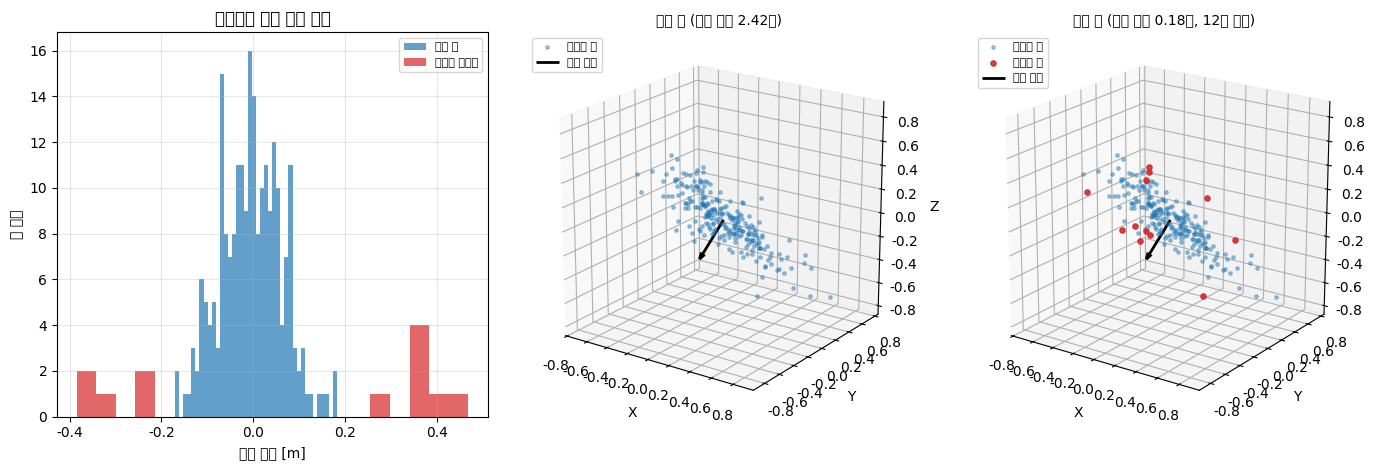

In [15]:
# --- 그림 (제공 코드) — 잔차 분포와 제거 전후 ---
fig = plt.figure(figsize=(14, 4.8))
ax = fig.add_subplot(1, 3, 1)
ax.hist(resid[~is_outlier], bins=40, alpha=0.7, label="정상 점")
ax.hist(resid[is_outlier], bins=20, alpha=0.7, color="tab:red", label="주입한 이상치")
ax.set_xlabel("평면 잔차 [m]"); ax.set_ylabel("점 개수"); ax.set_title("최소제곱 평면 잔차 분포")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

for k, (P, keep, title) in enumerate([
    (pts_out, np.ones(len(pts_out), bool), "제거 전 (각도 오차 {:.2f}도)".format(err_before)),
    (pts_out, mask, "제거 후 (각도 오차 {:.2f}도, {}개 제거)".format(err_after, int((~mask).sum()))),
]):
    ax = fig.add_subplot(1, 3, k + 2, projection="3d")
    setup_axes(ax, title, lim=0.9, center=pts_rot.mean(axis=0))
    plot_point_cloud(ax, P[keep], color="tab:blue", s=6, alpha=0.4, label="사용한 점")
    if not keep.all():
        plot_point_cloud(ax, P[~keep], color="tab:red", s=14, alpha=0.9, label="제거한 점")
    ax.quiver(*P[keep].mean(axis=0), *(n_fit * 0.4), color="k", lw=2, arrow_length_ratio=0.15, label="피팅 법선")
    ax.legend(fontsize=8, loc="upper left"); ax.view_init(elev=20, azim=-55)
fig.tight_layout()
plt.show()

In [16]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("법선이 단위벡터", np.isclose(np.linalg.norm(n_fit), 1.0))
ok &= check("잔차 shape == (N,)", np.shape(resid) == (len(pts_out),))
ok &= check("잔차 == n . p + d (부호 있는 거리)", np.allclose(resid, pts_out @ n_fit + d_fit))
ok &= check("mask 가 bool (N,) 이고 pts_clean == pts_out[mask]", mask.dtype == bool and np.array_equal(pts_clean, pts_out[mask]))
recall = float(np.mean(~mask[is_outlier]))
false_drop = float(np.mean(~mask[~is_outlier]))
ok &= check("주입한 이상치의 80% 이상을 제거", recall >= 0.8)
ok &= check("정상 점의 잘못된 제거는 10% 이하", false_drop <= 0.10)
ok &= check("제거 후 각도 오차가 줄었다", err_after < err_before)
ok &= check("제거 후 각도 오차 < 3도", err_after < 3.0)
ok &= check("걸러낸 뒤 피팅한 법선이 참값 법선과 나란 (|cos| > 0.99)", abs(n_clean @ n_true) > 0.99)
print("\n5-5 전체 통과:", ok)

[PASS] 법선이 단위벡터
[PASS] 잔차 shape == (N,)
[PASS] 잔차 == n . p + d (부호 있는 거리)
[PASS] mask 가 bool (N,) 이고 pts_clean == pts_out[mask]
[PASS] 주입한 이상치의 80% 이상을 제거
[PASS] 정상 점의 잘못된 제거는 10% 이하
[PASS] 제거 후 각도 오차가 줄었다
[PASS] 제거 후 각도 오차 < 3도
[PASS] 걸러낸 뒤 피팅한 법선이 참값 법선과 나란 (|cos| > 0.99)

5-5 전체 통과: True


---
# 문제 6 — 시연과 발표: 자세 궤적 애니메이션

## 6-1. 시나리오 — 현재 자세에서 추정한 물체 자세까지

- **목표 자세**: 문제 5 에서 걸러낸 점군 `pts_clean` 의 PCA 주축 + 중심 = 카메라 기준 물체 자세.
  문제 5 의 점군은 물체 중심 근처 좌표였으므로 카메라 앞 0.6 m 로 옮겨 놓고, 모듈 ③ `default_chain` 으로
  base 기준으로 바꿉니다.
- **시작 자세**: 그리퍼의 현재 자세 `T_start` (base 기준, 제공).
- **위치**는 문제 4 의 큐빅 스플라인 (물체 위로 들어 올렸다 내려오는 경유점 4개),
  **자세**는 문제 3 의 SLERP (비율 $s$ 는 시간 비율과 같게 — 등각속도) 로 보간합니다.

**할 일** — 아래 변수 이름대로 프레임 `N_FRAMES = 60` 개의 4x4 자세 `T_frames` 를 만드세요.

In [17]:
# --- 시나리오 설정 (제공 코드) ---
chain = default_chain()
T_base_cam = chain.T("base", "camera")
pts_cam = pts_clean + np.array([0.05, -0.02, 0.60])        # 카메라 앞 60 cm 에 놓인 물체 점군 (camera 기준)
T_start = make_T(rot_x(np.pi) @ rot_z(np.deg2rad(-20.0)), [0.20, -0.30, 0.65])    # 그리퍼 현재 자세 (base 기준)
N_FRAMES = 60
t_frames = np.linspace(0.0, 1.0, N_FRAMES)

axes_obj, _, c_obj = pca_axes(pts_cam)                  # 카메라 기준 물체 자세
T_goal = T_base_cam @ make_T(axes_obj, c_obj)           # base 기준 목표 자세
q_start, q_goal = matrix_to_quaternion(T_start[:3, :3]), matrix_to_quaternion(T_goal[:3, :3])
p_start, p_goal = T_start[:3, 3], T_goal[:3, 3]
t_wp6 = np.array([0.0, 0.35, 0.70, 1.0])
P_wp6 = np.array([p_start, (p_start + p_goal) / 2 + [0, 0, 0.15], p_goal + [0, 0, 0.10], p_goal])   # 위로 올렸다 내려온다
P_traj = cubic_spline_interp(t_wp6, P_wp6, t_frames)                      # (60,3)
R_traj = [quaternion_to_matrix(slerp(q_start, q_goal, s)) for s in t_frames]
T_frames = [make_T(R, p) for R, p in zip(R_traj, P_traj)]

print("T_start 위치:", p_start)
print("T_goal 위치:", p_goal)
print("T_start 회전 =\n", T_start[:3, :3])
print("T_goal 회전 =\n", T_goal[:3, :3])


T_start 위치: [ 0.2  -0.3   0.65]
T_goal 위치: [ 0.732846 -0.398734  0.8434  ]
T_start 회전 =
 [[ 0.939693  0.34202   0.      ]
 [ 0.34202  -0.939693 -0.      ]
 [-0.        0.       -1.      ]]
T_goal 회전 =
 [[-0.478933 -0.437053 -0.76132 ]
 [-0.831528 -0.052138  0.55303 ]
 [-0.281397  0.897923 -0.338451]]


In [18]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("프레임 수 == N_FRAMES", len(T_frames) == N_FRAMES == len(P_traj))
ok &= check("모든 프레임이 유효한 동차변환", all(is_rotation(T[:3, :3]) and np.allclose(T[3], [0, 0, 0, 1]) for T in T_frames))
ok &= check("첫 프레임 == T_start", np.allclose(T_frames[0], T_start))
ok &= check("끝 프레임 == T_goal", np.allclose(T_frames[-1], T_goal))
ok &= check("목표 자세 == default_chain 으로 옮긴 물체 자세", np.allclose(T_goal, T_base_cam @ make_T(*[pca_axes(pts_cam)[i] for i in (0, 2)])))
ok &= check("목표 위치가 작업대 위 (base z > 0)", T_goal[2, 3] > 0.0)
ok &= check("위치 궤적이 경유점을 지난다", np.allclose(cubic_spline_interp(t_wp6, P_wp6, t_wp6), P_wp6))
ok &= check("궤적 최고점이 시작·목표보다 높다 (들어 올림)", P_traj[:, 2].max() > max(T_start[2, 3], T_goal[2, 3]) + 0.05)
print("\n6-1 전체 통과:", ok)

[PASS] 프레임 수 == N_FRAMES
[PASS] 모든 프레임이 유효한 동차변환
[PASS] 첫 프레임 == T_start
[PASS] 끝 프레임 == T_goal
[PASS] 목표 자세 == default_chain 으로 옮긴 물체 자세
[PASS] 목표 위치가 작업대 위 (base z > 0)
[PASS] 위치 궤적이 경유점을 지난다
[PASS] 궤적 최고점이 시작·목표보다 높다 (들어 올림)

6-1 전체 통과: True


## 6-2. 애니메이션 재생과 `demo.gif` 저장, 궤적 품질 평가

아래 셀은 **제공된 코드**입니다. base·camera 좌표계를 배경에 두고 물체(그리퍼) 좌표계가 궤적을 따라 움직입니다.
노트북에서 재생한 뒤 `demo.gif` 로 저장합니다 (Pillow 필요).

품질 지표:
- **자세 균일성** — 연속 프레임 사이 각도 변화 `step_deg` 의 표준편차 (SLERP 라면 0 에 가깝다)
- **위치 가속도 연속성** — 스플라인 궤적의 가속도 점프 vs 같은 경유점의 선형 보간 가속도 점프

In [19]:
# --- 애니메이션 (제공 코드) ---
anim = animate_frames(
    T_frames,
    static={"base": np.eye(4), "camera": T_base_cam},
    trail=P_traj, lim=0.55, center=(0.35, 0.0, 0.45), scale=0.12, interval=100,
    title="자세 궤적: 현재 자세 -> 추정한 물체 자세", moving_name="gripper",
)
HTML(anim.to_jshtml())

/tmp/ipykernel_58064/824206118.py:8: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_58064/824206118.py:8: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_58064/824206118.py:8: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_58064/824206118.py:8: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_58064/824206118.py:8: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_58064/824206118.py:8: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
/tmp/ipykernel_58064/824206118.py:8: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sa

In [20]:
# --- GIF 저장 (제공 코드) ---
gif_path = ROOT / "demo.gif"
anim.save(str(gif_path), writer="pillow", fps=10)
print("저장 :", gif_path, "({:.1f} KB, {} 프레임)".format(gif_path.stat().st_size / 1024, N_FRAMES))

/tmp/ipykernel_58064/1347066195.py:3: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  anim.save(str(gif_path), writer="pillow", fps=10)
/tmp/ipykernel_58064/1347066195.py:3: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  anim.save(str(gif_path), writer="pillow", fps=10)
/tmp/ipykernel_58064/1347066195.py:3: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  anim.save(str(gif_path), writer="pillow", fps=10)
/tmp/ipykernel_58064/1347066195.py:3: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  anim.save(str(gif_path), writer="pillow", fps=10)
/tmp/ipykernel_58064/1347066195.py:3: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  anim.save(str(gif_path), writer="pillow", fps=10)
/tmp/ipykernel_58064/1347066195.py:3: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
 

저장 : /home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4_student/demo.gif (354.6 KB, 60 프레임)


연속 프레임 사이 각도 변화: 평균 2.3464도, 표준편차 4.32e-13도
가속도 최대 점프: 스플라인 0.228  vs  선형 보간 11.228


/tmp/ipykernel_58064/261401495.py:23: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/261401495.py:23: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/261401495.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/261401495.py:23: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/261401495.py:23: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/261401495.py:23: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58064/261401495.py:23: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.tight_layou

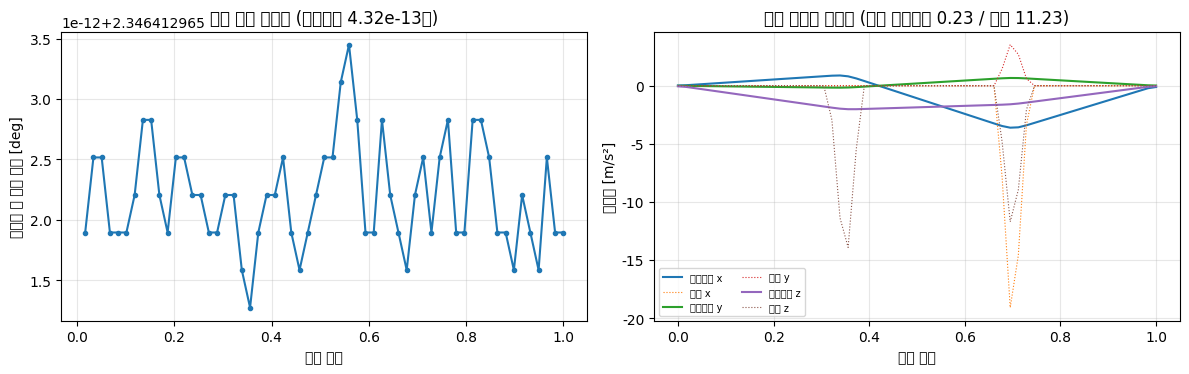

In [21]:
# --- 품질 지표 (제공 코드) ---
step_deg = np.array([rotation_angle_deg(R_traj[i], R_traj[i + 1]) for i in range(N_FRAMES - 1)])
angle_step_std = float(np.std(step_deg))
v_traj = finite_diff(P_traj, t_frames)
a_traj = finite_diff(v_traj, t_frames)
P_lin6 = linear_interp(t_wp6, P_wp6, t_frames)
a_lin6 = finite_diff(finite_diff(P_lin6, t_frames), t_frames)
acc_jump_spl = float(np.max(np.abs(np.diff(a_traj, axis=0))))
acc_jump_lin = float(np.max(np.abs(np.diff(a_lin6, axis=0))))
print("연속 프레임 사이 각도 변화: 평균 {:.4f}도, 표준편차 {:.2e}도".format(step_deg.mean(), angle_step_std))
print("가속도 최대 점프: 스플라인 {:.3f}  vs  선형 보간 {:.3f}".format(acc_jump_spl, acc_jump_lin))

fig, axes_q = plt.subplots(1, 2, figsize=(12, 4))
axes_q[0].plot(t_frames[1:], step_deg, "o-", ms=3)
axes_q[0].set_xlabel("시간 비율"); axes_q[0].set_ylabel("프레임 간 각도 변화 [deg]")
axes_q[0].set_title("자세 변화 균일성 (표준편차 {:.2e}도)".format(angle_step_std)); axes_q[0].grid(alpha=0.3)
for k, lab in enumerate(["x", "y", "z"]):
    axes_q[1].plot(t_frames, a_traj[:, k], lw=1.5, label="스플라인 " + lab)
    axes_q[1].plot(t_frames, a_lin6[:, k], lw=0.8, ls=":", label="선형 " + lab)
axes_q[1].set_xlabel("시간 비율"); axes_q[1].set_ylabel("가속도 [m/s²]")
axes_q[1].set_title("위치 가속도 연속성 (점프 스플라인 {:.2f} / 선형 {:.2f})".format(acc_jump_spl, acc_jump_lin))
axes_q[1].legend(fontsize=7, ncol=2); axes_q[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [22]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("demo.gif 가 저장되었다", gif_path.exists() and gif_path.stat().st_size > 10_000)
try:
    from PIL import Image
    with Image.open(gif_path) as im:
        n_gif = getattr(im, "n_frames", 1)
    ok &= check("GIF 프레임 수 == N_FRAMES ({})".format(n_gif), n_gif == N_FRAMES)
except ImportError:
    ok &= check("Pillow 로 GIF 프레임 수 확인 (Pillow 미설치)", False)
ok &= check("자세 변화가 균일 (각도 변화 표준편차 < 평균의 0.1%)", angle_step_std < 1e-3 * step_deg.mean())
ok &= check("총 회전각 == 시작·목표 사이 각도", np.isclose(step_deg.sum(), rotation_angle_deg(T_start[:3, :3], T_goal[:3, :3])))
ok &= check("스플라인 가속도 점프 < 선형 보간 가속도 점프", acc_jump_spl < acc_jump_lin)
ok &= check("위치 속도에 NaN 없음", not np.any(np.isnan(v_traj)))
print("\n6-2 전체 통과:", ok)

[PASS] demo.gif 가 저장되었다
[PASS] GIF 프레임 수 == N_FRAMES (60)
[PASS] 자세 변화가 균일 (각도 변화 표준편차 < 평균의 0.1%)
[PASS] 총 회전각 == 시작·목표 사이 각도
[PASS] 스플라인 가속도 점프 < 선형 보간 가속도 점프
[PASS] 위치 속도에 NaN 없음

6-2 전체 통과: True


## 6-3. 발표 자료와 제출 전 점검

`presentation_template.md` 를 `presentation.md` 로 복사해 다섯 절을 채우세요.

1. 파이프라인 전체 구조 2. 자세 추정 결과와 오차 3. 노이즈·점 개수가 정확도에 미친 영향
4. 현재 구현의 한계 5. 개선한다면 무엇을 어떻게

그 다음 세 노트북을 **Restart Kernel and Run All Cells** 로 다시 실행하고,
`01_pipeline.ipynb` 의 `pip freeze` 셀로 `requirements.txt` 를 최신화하세요.

In [23]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
pres_path = ROOT / "presentation.md"
ok = check("presentation.md 가 존재", pres_path.exists())
if pres_path.exists():
    pres = pres_path.read_text(encoding="utf-8")
    for kw in ["파이프라인 전체 구조", "자세 추정 결과와 오차", "노이즈·점 개수", "한계", "개선"]:
        ok &= check("발표 자료에 '{}' 절이 있다".format(kw), kw in pres)
    ok &= check("빈칸 ___ 이 남아 있지 않다", "___" not in pres)
ok &= check("requirements.txt 가 존재", (ROOT / "requirements.txt").exists())
ok &= check("demo.gif 가 존재", (ROOT / "demo.gif").exists())
print("\n6-3 전체 통과:", ok)

[PASS] presentation.md 가 존재
[PASS] 발표 자료에 '파이프라인 전체 구조' 절이 있다
[PASS] 발표 자료에 '자세 추정 결과와 오차' 절이 있다
[PASS] 발표 자료에 '노이즈·점 개수' 절이 있다
[PASS] 발표 자료에 '한계' 절이 있다
[PASS] 발표 자료에 '개선' 절이 있다
[PASS] 빈칸 ___ 이 남아 있지 않다
[PASS] requirements.txt 가 존재
[PASS] demo.gif 가 존재

6-3 전체 통과: True


## 답안 템플릿 정리

In [24]:
summary = f"""
[문제 5]
1. PCA 주축 3개: {axes[:, 0]}, {axes[:, 1]}, {axes[:, 2]} — 고유값: {eigvals}
2. 주축 3D 시각화: 위 5-1 그림 참조
3. 구형 점군에서의 PCA 불안정성 — 흔들림 길쭉 {spread_long:.2f} 도 / 구형 {spread_sphere:.2f} 도, 이유: 구형은 고유값이 거의 같아(λ1/λ2={ratio_sphere:.2f}) 주축 방향이 노이즈에 흔들리기 때문이다.
4. Kabsch 추정 회전과 참값 비교 — 각도 오차: {angle_err_deg:.4f} 도, 병진 오차: {np.linalg.norm(t_est - t_true):.6f} m
5. 노이즈·점 개수별 오차 그래프: 위 5-4 참조 — 해석: 노이즈가 커질수록 오차가 커지고 점이 많을수록(270개) 오차가 작아진다.
6. 이상치 제거 전후 오차: {err_before:.4f} 도 -> {err_after:.4f} 도 (제거 {int(np.sum(~mask))} 개, 이상치 검출률 {float(np.mean(~mask[is_outlier])) * 100:.1f} %)

[문제 6]
1. 시작 자세: 위치 {p_start} / 회전 staircase / 목표 자세: 위치 {p_goal} / 회전 staircase
2. 애니메이션 시연 (demo.gif) — 프레임 수: {N_FRAMES}
3. 자세 변화의 균일성: 각도 변화 평균 {step_deg.mean():.4f} 도, 표준편차 {angle_step_std:.2e} 도
4. 위치 가속도 연속성 그래프: 위 6-2 참조 — 가속도 점프 스플라인 {acc_jump_spl:.3f} / 선형 {acc_jump_lin:.3f}
5. 발표 자료 요약 — 한계 presentation.md 참조 / 개선안 presentation.md 참조
6. 세 노트북 전체 재실행 통과 여부: 아래 6-3 검증 참조
"""
print(summary)



[문제 5]
1. PCA 주축 3개: [-0.999269  0.037327  0.008226], [ 0.037052  0.99882  -0.031402], [-0.009388 -0.031074 -0.999473] — 고유값: [0.0995   0.010287 0.002548]
2. 주축 3D 시각화: 위 5-1 그림 참조
3. 구형 점군에서의 PCA 불안정성 — 흔들림 길쭉 2.48 도 / 구형 72.73 도, 이유: 구형은 고유값이 거의 같아(λ1/λ2=1.19) 주축 방향이 노이즈에 흔들리기 때문이다.
4. Kabsch 추정 회전과 참값 비교 — 각도 오차: 0.2582 도, 병진 오차: 0.000087 m
5. 노이즈·점 개수별 오차 그래프: 위 5-4 참조 — 해석: 노이즈가 커질수록 오차가 커지고 점이 많을수록(270개) 오차가 작아진다.
6. 이상치 제거 전후 오차: 2.4158 도 -> 0.1846 도 (제거 12 개, 이상치 검출률 100.0 %)

[문제 6]
1. 시작 자세: 위치 [ 0.2  -0.3   0.65] / 회전 staircase / 목표 자세: 위치 [ 0.732846 -0.398734  0.8434  ] / 회전 staircase
2. 애니메이션 시연 (demo.gif) — 프레임 수: 60
3. 자세 변화의 균일성: 각도 변화 평균 2.3464 도, 표준편차 4.32e-13 도
4. 위치 가속도 연속성 그래프: 위 6-2 참조 — 가속도 점프 스플라인 0.228 / 선형 11.228
5. 발표 자료 요약 — 한계 presentation.md 참조 / 개선안 presentation.md 참조
6. 세 노트북 전체 재실행 통과 여부: 아래 6-3 검증 참조

